# **<span style="font-family: Arial">Financial Fraud Detection - Data Cleaning, Wrangling & Preprocessing </span>**

**Author:** Ozor Moya

**Date:** 04/19/2026

**Goal:** Use insights from the EDA to clean the dataset, drop irrelevant features, engineer new ones, and export a model-ready CSV.

---
### 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

---
### 2. Load dataset

In [2]:
df = pd.read_csv('/Users/sa02/class-projects/EOP-Project/P2PortfolioProject/Data/PS_20174392719_1491204439457_log.csv')
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


- Here, I used the original csv file since there is no data cleaning happened in my EDA.

---
### 3. Check missing values and Duplicates

- Although in EDA I discovered that there in no null and duplicated values in this dataset, it is safer to always verify it first.

In [3]:
print(df.isnull().sum())

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


In [5]:
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


---
### 4. Filtering out Fraud-Relevant Transaction from Type column

- In my EDA, it showed that fraud **only occurs in TRANSFER and CASH_OUT** transactions. Including the other types (PAYMENT, DEBIT, CASH_IN) adds noise — they have zero positive fraud cases and would make the class imbalance even worse.

In [4]:
df = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])].copy()
df.reset_index(drop=True, inplace=True)
print(df['type'].value_counts())

type
CASH_OUT    2237500
TRANSFER     532909
Name: count, dtype: int64


---
### 5. Dropping columns

- I will be dropping these columns as stated on my EDA.

In [5]:
cols_to_drop = ['nameOrig', 'nameDest', 'isFlaggedFraud']
df.drop(columns=cols_to_drop, inplace=True)

In [8]:
df.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
0,1,TRANSFER,181.00,181.0,0.0,0.0,0.00,1
1,1,CASH_OUT,181.00,181.0,0.0,21182.0,0.00,1
2,1,CASH_OUT,229133.94,15325.0,0.0,5083.0,51513.44,0
3,1,TRANSFER,215310.30,705.0,0.0,22425.0,0.00,0
4,1,TRANSFER,311685.89,10835.0,0.0,6267.0,2719172.89,0


- I dropped `nameOrig` and `nameDest` because they contain no predictive value
- I also dropped `isFlaggedFraud` because it might leak information.

---
### 5. Feature Engineering

- Two balance difference features are engineered to address multicollinearity identified in EDA. BalancediffOrig captures how much the sender's balance decreased — directly measuring the account drainage pattern that EDA identified as the strongest fraud signal. BalancediffDest captures how much the destination balance increased. These two features replace four correlated columns, reducing redundancy while preserving and concentrating the most meaningful fraud signals.`newbalanceDest` has r=0.98 which means they share multicollinearity. I will engineer two new features based on the balance difference hypothesis from my EDA.

In [ ]:
# Balance error features
df['BalancediffOrig'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['BalancediffDest'] = df['newbalanceDest'] - df['oldbalanceDest']

# Inspect these in relation to fraud
print('Balance Difference — Origin (mean by class)')
print(df.groupby('isFraud')['BalancediffOrig'].agg(['mean', 'std', 'min', 'max']))
print()
print('Balance Difference — Destination (mean by class)')
print(df.groupby('isFraud')['BalancediffDest'].agg(['mean', 'std', 'min', 'max']))

Balance Difference — Origin (mean by class)
                 mean           std       min          max
isFraud                                                   
0        2.731199e+04  6.146932e+04 -26575.26   4164236.31
1        1.457275e+06  2.396099e+06      0.00  10000000.00

Balance Difference — Destination (mean by class)
                  mean           std         min           max
isFraud                                                       
0        345025.821522  1.174989e+06 -9681485.46  1.056878e+08
1        735457.998071  1.856984e+06  -315226.07  1.491511e+07


In [7]:
df.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,BalancediffOrig,BalancediffDest
0,1,TRANSFER,181.00,181.0,0.0,0.0,0.00,1,181.0,0.00
1,1,CASH_OUT,181.00,181.0,0.0,21182.0,0.00,1,181.0,-21182.00
2,1,CASH_OUT,229133.94,15325.0,0.0,5083.0,51513.44,0,15325.0,46430.44
3,1,TRANSFER,215310.30,705.0,0.0,22425.0,0.00,0,705.0,-22425.00
4,1,TRANSFER,311685.89,10835.0,0.0,6267.0,2719172.89,0,10835.0,2712905.89


- Just checking if the feature engineered columns are successfully implemented.

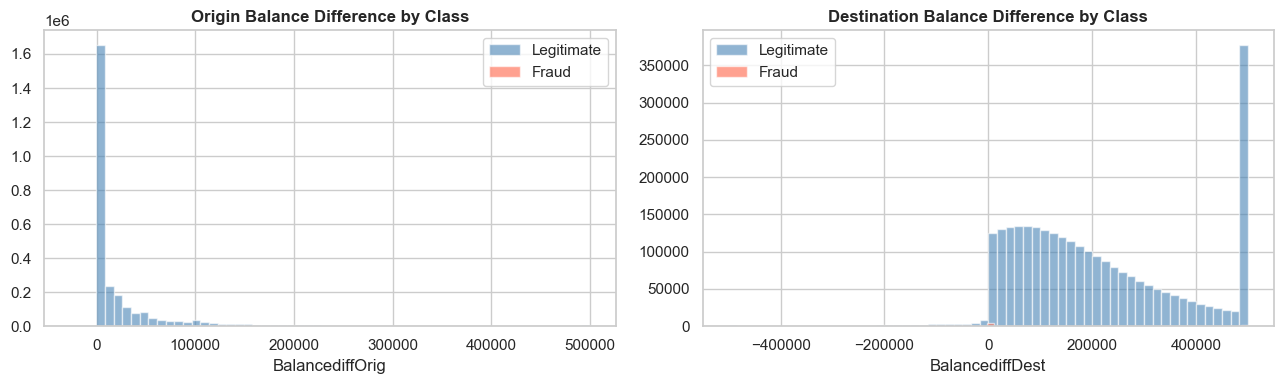

In [9]:
# Visualise the new features
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for col, ax, title in [
    ('BalancediffOrig', axes[0], 'Origin Balance Difference by Class'),
    ('BalancediffDest', axes[1], 'Destination Balance Difference by Class')
]:
    for label, color in [(0, 'steelblue'), (1, 'tomato')]:
        vals = df[df['isFraud'] == label][col].clip(-5e5, 5e5)
        ax.hist(vals, bins=60, alpha=0.6, color=color,
                label='Fraud' if label else 'Legitimate')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.legend()

plt.tight_layout()
plt.show()

- The engineered balance difference features show contrasting fraud signals. `BalancediffOrig` shows clear separation — legitimate transactions cluster near zero while fraud transactions show consistently higher drainage values. `BalancediffDest` shows heavy overlap between classes confirming it is a weaker predictor. This visualization validates the feature importance findings.

---
### 6. One-Hot Encode `type`

- Here I will convert `type` into binary dummy columns using one-hot encoding. With only two values (TRANSFER, CASH_OUT), this adds one new column.

- I use `drop_first=True` to avoid multicollinearity (one dummy is redundant when we already know the other).

In [10]:
df = pd.get_dummies(df, columns=['type'], drop_first=True)

print(f'Shape after encoding: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Shape after encoding: (2770409, 10)
Columns: ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'BalancediffOrig', 'BalancediffDest', 'type_TRANSFER']


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,BalancediffOrig,BalancediffDest,type_TRANSFER
0,1,181.00,181.0,0.0,0.0,0.00,1,181.0,0.00,True
1,1,181.00,181.0,0.0,21182.0,0.00,1,181.0,-21182.00,False
2,1,229133.94,15325.0,0.0,5083.0,51513.44,0,15325.0,46430.44,False
3,1,215310.30,705.0,0.0,22425.0,0.00,0,705.0,-22425.00,True
4,1,311685.89,10835.0,0.0,6267.0,2719172.89,0,10835.0,2712905.89,True


- One hot encoding is applied to the type column. Since only two transaction types remain after filtering, drop_first=True is used to avoid redundancy — resulting in a single binary column type_TRANSFER where 1 represents TRANSFER and 0 represents CASH_OUT.

---
### 7. Final Data Quality Check

- Before saving, I will do a final audit of cleaned dataset: data types, null counts, and class balance.

In [11]:
print('=== Final Dataset Summary ===')
print(f'Shape: {df.shape}')
print(f'\nNull values:')
print(df.isnull().sum())
print(f'\nDtypes:')
print(df.dtypes)
print(f'\nFraud class distribution:')
print(df['isFraud'].value_counts())
print(f'Fraud rate: {df["isFraud"].mean() * 100:.4f}%')

=== Final Dataset Summary ===
Shape: (2770409, 10)

Null values:
step               0
amount             0
oldbalanceOrg      0
newbalanceOrig     0
oldbalanceDest     0
newbalanceDest     0
isFraud            0
BalancediffOrig    0
BalancediffDest    0
type_TRANSFER      0
dtype: int64

Dtypes:
step                 int64
amount             float64
oldbalanceOrg      float64
newbalanceOrig     float64
oldbalanceDest     float64
newbalanceDest     float64
isFraud              int64
BalancediffOrig    float64
BalancediffDest    float64
type_TRANSFER         bool
dtype: object

Fraud class distribution:
isFraud
0    2762196
1       8213
Name: count, dtype: int64
Fraud rate: 0.2965%


- All looks good, time to save this cleaned csv file.

---
### 8. Save processed dataset

In [12]:
df.to_csv('/Users/sa02/class-projects/EOP-Project/P2PortfolioProject/Data/model_ready.csv', index=False)
print(f'File shape: {df.shape}')

File shape: (2770409, 10)
